In [1]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.ticker as ticker
from ipywidgets import interact_manual, widgets
from IPython.display import display

from mrmustard import settings
from mrmustard.lab import SqueezedVacuum, Vacuum, Number
from mrmustard.lab.transformations import Dgate, BSgate, Attenuator

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0f1117",
    "axes.facecolor":    "#0f1117",
    "axes.edgecolor":    "#2e3140",
    "axes.labelcolor":   "#c8ccd8",
    "axes.titlecolor":   "#e8eaf0",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "axes.titlepad":     14,
    "axes.labelpad":     8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.color":       "#6b7080",
    "ytick.color":       "#6b7080",
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "grid.color":        "#1e2130",
    "grid.linewidth":    0.8,
    "text.color":        "#c8ccd8",
    "font.family":       "monospace",
    "text.usetex":       False,
})

In [2]:
prob_pPNRD_experimental = np.array([
    [9.99547105e-01, 1.66281358e-01, 5.02737436e-02, 2.23175788e-02, 5.65268661e-08, 5.75890740e-15, 6.31990572e-03, 3.44978360e-04, 8.68996414e-12, 3.88600801e-15, 5.04289076e-15, 6.19170166e-15, 2.02077936e-14],
    [4.51739011e-04, 8.31413411e-01, 2.23968130e-01, 1.84601871e-02, 1.47452826e-03, 2.60370192e-03, 3.79817832e-05, 1.04121310e-12, 6.88728481e-17, 6.43954127e-15, 9.93480164e-15, 8.27693406e-15, 3.65433940e-15],
    [1.15667853e-06, 2.30523180e-03, 7.16360334e-01, 3.35625687e-01, 5.17004859e-03, 5.72086900e-07, 1.07650364e-15, 1.79659200e-13, 4.14035662e-16, 4.07549278e-13, 1.97803310e-13, 1.15421147e-13, 5.25569035e-13],
    [3.09172015e-13, 6.35689228e-15, 9.12598263e-03, 6.06083387e-01, 4.63893280e-01, 1.17787563e-03, 3.73711956e-12, 3.63613832e-13, 4.24727711e-14, 5.24641224e-13, 9.87401360e-13, 7.51758331e-13, 5.95429768e-13],
    [8.72478830e-16, 3.14298163e-11, 2.41265004e-05, 1.34212034e-02, 5.29075711e-01, 4.90112590e-01, 2.30318463e-11, 3.56422270e-12, 6.27528332e-16, 1.15905268e-15, 3.01461569e-15, 2.25342181e-15, 2.57596188e-15],
    [5.90459350e-14, 1.03396564e-12, 3.44783175e-11, 3.88058812e-03, 3.86375221e-04, 5.06105261e-01, 4.90248665e-01, 5.55458423e-17, 4.64701355e-15, 3.30352863e-15, 1.01876000e-14, 2.24533012e-15, 9.22546907e-14],
    [7.58187762e-14, 8.15063683e-13, 1.92982115e-04, 2.28196249e-05, 1.42383399e-12, 5.57110896e-14, 5.03393466e-01, 4.63753855e-01, 1.32078002e-11, 1.53592265e-16, 1.00308944e-16, 9.32379267e-17, 8.07689508e-17],
    [7.53741062e-14, 1.02034502e-12, 4.71817766e-05, 1.88561174e-04, 9.52171604e-13, 7.66895232e-17, 4.44638384e-16, 5.35901166e-01, 3.97727382e-01, 1.14983867e-15, 4.50182991e-16, 3.98386146e-16, 2.35633666e-13],
    [7.36195842e-14, 9.07950143e-13, 7.51945918e-06, 1.60020054e-15, 6.96467992e-13, 1.90327052e-13, 1.71780590e-15, 1.20987776e-13, 6.02272618e-01, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
])

# Ideal M pixel pseudo-PNRD POVM element matrix P^M(n|k) 
# If use_data=True, use experimental matrix with crop/pad behavior.
def prob_pPNRD(
    M: int | None = None,
    eta: float | None = None,
    k_max: int = 0,
    n_max: int = 0,
    use_data: bool = True,
) -> np.ndarray:
    """
    Return matrix P[n,k] = P(n|k).

    Modes
    -----
    use_data=True:
        Use the experimental matrix, crop to requested
        support and pad if needed. Extra k columns uses 1.0 at
        n=8 and 0.0 elsewhere.

    use_data=False:
        Compute ideal pseudo-PNRD response for M bins and include detector
        efficiency eta by binomial loss mixing.
    """
    if k_max < 0 or n_max < 0:
        raise ValueError("k_max and n_max must be non-negative integers.")

    if use_data:
        exp_data = prob_pPNRD_experimental

        out = np.zeros((n_max + 1, k_max + 1), dtype=float)
        n_copy = min(n_max + 1, exp_data.shape[0])
        k_copy = min(k_max + 1, exp_data.shape[1])
        out[:n_copy, :k_copy] = exp_data[:n_copy, :k_copy]

        # for extra k columns, set P(n=8|k)=1 and all other rows to 0.
        if k_max + 1 > exp_data.shape[1] and n_max >= 8:
            out[8, exp_data.shape[1]:] = 1.0

        return out

    if M is None or eta is None:
        raise ValueError("When use_data=False, both M and eta must be provided.")
    if M <= 0:
        raise ValueError("M must be a positive integer.")
    if not (0.0 <= eta <= 1.0):
        raise ValueError("eta must be in [0, 1].")

    # Ideal pseudo-PNRD without detection inefficiency.
    n_compute = min(n_max, M)
    P_ideal = np.zeros((n_compute + 1, k_max + 1), dtype=float)
    P_ideal[0, 0] = 1.0

    for k in range(k_max):
        n_lim = min(k, n_compute)
        n_vals = np.arange(n_lim + 1)
        P_ideal[n_vals, k + 1] += (n_vals / M) * P_ideal[n_vals, k]

        n_next = np.arange(1, min(n_lim + 1, n_compute) + 1)
        P_ideal[n_next, k + 1] += ((M - (n_next - 1)) / M) * P_ideal[n_next - 1, k]

    for n in range(n_compute + 1):
        P_ideal[n, :n] = 0.0

    # Include detector efficiency: m~Binomial(k, eta), then clicks from m photons.
    from math import comb

    P = np.zeros((n_compute + 1, k_max + 1), dtype=float)
    for k in range(k_max + 1):
        m_vals = np.arange(k + 1)
        # Compute binomial pmf safely without external dependencies.
        binom = np.array([comb(k, int(m)) for m in m_vals], dtype=float)
        weights = binom * (eta ** m_vals) * ((1.0 - eta) ** (k - m_vals))
        P[:, k] = P_ideal[:, :k + 1] @ weights

    np.clip(P, 0.0, 1.0, out=P)

    if n_compute < n_max:
        P = np.vstack([P, np.zeros((n_max - n_compute, k_max + 1), dtype=float)])

    return P

##########################################################################################
# Photon number distributions of different states after loss and/or displacement

# Squeezed vacuum
def squeezed_distribution(r, r_in_dB=True, squeezing_dir=0, Loss_sq=0.0, Loss_det=0.0, disp=0.0, n_cutoff=20, use_pPNRD=False):
    
    if r_in_dB:
        r = r / (20 * np.log10(np.e))
    
    with settings(DEFAULT_FOCK_SIZE=n_cutoff, AUTOSHAPE_MIN=n_cutoff, AUTOSHAPE_MAX=n_cutoff):
        state = SqueezedVacuum(0, r, phi=squeezing_dir) >> Attenuator(0, 1-Loss_sq) >> Dgate(0, disp) >> Attenuator(0, 1-Loss_det)
        state = state.normalize()
        rho = state.dm().fock_array(n_cutoff)
        population = np.real(np.diagonal(rho))

    if use_pPNRD:
        photon_support = len(population) - 1
        detector_POVM = prob_pPNRD(
            use_data=True,
            k_max=photon_support,
            n_max=photon_support
        )
        detected_distribution = np.einsum("ij,j->i", detector_POVM, population)
        return population, detected_distribution

    return population, None

# Photon-subtracted squeezed vacuum
def photon_subtracted_distribution(r, r_in_dB=True, squeezing_dir=0, R=0.01, Loss_sq=0.0, Loss_ps=0.0, Loss_det=0.0, disp=0.0, n_cutoff=20, use_pPNRD=False):
    
    if r_in_dB:
        r = r / (20 * np.log10(np.e))
    
    theta = np.arcsin(np.sqrt(R))
    
    with settings(DEFAULT_FOCK_SIZE=n_cutoff, AUTOSHAPE_MIN=n_cutoff, AUTOSHAPE_MAX=n_cutoff):
        state = SqueezedVacuum(0, r, phi=squeezing_dir) >> Vacuum((1)) >> Attenuator(0, 1-Loss_sq) \
                >> BSgate(modes=(0, 1), theta=theta) >> Attenuator(0, 1-Loss_ps) >> Dgate(0, disp) >> Attenuator(0, 1-Loss_det)
        substracted_state = state >> Number(1, 1).dual
        rho = substracted_state.normalize().dm().fock_array(n_cutoff)
        population = np.real(np.diagonal(rho))

    if use_pPNRD:
        photon_support = len(population) - 1
        detector_POVM = prob_pPNRD(
            use_data=True,
            k_max=photon_support,
            n_max=photon_support,
        )
        detected_distribution = np.einsum("ij,j->i", detector_POVM, population)
        return population, detected_distribution

    return population, None

In [3]:
squeezings = np.linspace(0, 7, 200)
displ = np.linspace(0, 5, 1000)
r_sq = 0
cutoff = 50
angle = 0

loss_sq = 0.1
loss_det = 0.0

# Calculate populations for fixed settings while sweeping each parameter.
Pops_sq = []
for r in squeezings:
    pop, _ = squeezed_distribution(
        r=r, squeezing_dir=angle, Loss_sq=loss_sq, Loss_det=loss_det, disp=0, n_cutoff=cutoff
    )
    Pops_sq.append(pop)
Pops_sq = np.array(Pops_sq).T  # Rows: photon number n, Cols: squeezing values

Pops_disp = []
for d in displ:
    pop, _ = squeezed_distribution(
        r=r_sq, squeezing_dir=angle, Loss_sq=loss_sq, Loss_det=loss_det, disp=d, n_cutoff=cutoff
    )
    Pops_disp.append(pop)
Pops_disp = np.array(Pops_disp).T  # Rows: photon number n, Cols: displacement values

Losses = np.linspace(0, 1, 100)
Pops_loss = []
for loss_sq_i in Losses:
    pop, _ = squeezed_distribution(
        r=r_sq, squeezing_dir=angle, Loss_sq=loss_sq_i, Loss_det=loss_det, disp=0, n_cutoff=cutoff
    )
    Pops_loss.append(pop)
Pops_loss = np.array(Pops_loss).T  # Rows: photon number n, Cols: loss values

w_max_n = widgets.IntSlider(
    value=5,
    min=0,
    max=cutoff-1,
    step=1,
    description="Max n",
)

def update_plots(max_n):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for n in range(max_n+1):
        axes[0].plot(squeezings, Pops_sq[n], label=f"n={n}")
    axes[0].set_xlabel("Squeezing r [dB]")
    axes[0].set_ylabel("Population P(n)")
    axes[0].set_title("Squeezed state vs squeezing")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    for n in range(max_n+1):
        axes[1].plot(displ, Pops_disp[n], label=f"n={n}")
    axes[1].set_xlabel("Displacement d")
    axes[1].set_ylabel("Population P(n)")
    axes[1].set_title(rf"Squeezed state ($r={r_sq:.1f}$ dB) vs displacement")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)

    for n in range(max_n+1):
        axes[2].plot(Losses, Pops_loss[n], label=f"n={n}")
    axes[2].set_xlabel("Loss L")
    axes[2].set_ylabel("Population P(n)")
    axes[2].set_title(rf"Squeezed state ($r={r_sq:.1f}$ dB) vs loss")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

display(w_max_n)
widgets.interactive_output(update_plots, {"max_n": w_max_n})

IntSlider(value=5, description='Max n', max=49)

Output()

## Population Plots
1. (Displaced) squeezed state
2. (Displaced) photon subtracted squeezed state
3. Coherent light 

In [4]:
# ── Widgets ───────────────────────────────────────────────────────────────────
LAYOUT = widgets.Layout(width="400px")
STYLE  = {"description_width": "160px"}

w_r        = widgets.FloatSlider(value=7.5,   min=0,      max=14,    step=0.1,  description="Squeezing r [dB]",  layout=LAYOUT, style=STYLE)
w_angle    = widgets.FloatSlider(value=0,   min=0,      max=2*np.pi, step=0.01, description="Angle φ [rad]",    layout=LAYOUT, style=STYLE)
w_d        = widgets.FloatSlider(value=1.42,   min=-5,     max=5,     step=0.01,  description="Displacement d",   layout=LAYOUT, style=STYLE)
w_loss_sq  = widgets.FloatSlider(value=0.2, min=0,      max=1,     step=0.01, description="Loss (squeezing)", layout=LAYOUT, style=STYLE)
w_loss_det = widgets.FloatSlider(value=0.3, min=0,      max=1,     step=0.01, description="Loss (detection)", layout=LAYOUT, style=STYLE)
w_cutoff   = widgets.IntSlider(  value=30,  min=1,      max=100,   step=1,    description="Cutoff n",         layout=LAYOUT, style=STYLE)
w_show_P   = widgets.Checkbox(value=True,  description="Show P(n)", style=STYLE)
w_show_det = widgets.Checkbox(value=True, description="Show P_det(n)", style=STYLE)
w_show_st  = widgets.Checkbox(value=True, description="Show Fock state", style=STYLE)

def section(title, *ws):
    header = widgets.HTML(
        f"<div style='color:#5b8dee;font-size:10px;letter-spacing:.1em;padding:8px 0 2px'>{title}</div>"
    )
    return widgets.VBox([header, *ws], layout=widgets.Layout(margin="0 0 6px 0"))

controls = widgets.VBox([
    section("STATE",    w_r, w_angle, w_d),
    section("LOSSES",   w_loss_sq, w_loss_det),
    section("NUMERICS", w_cutoff),
    section("DISPLAY",  w_show_P, w_show_det, w_show_st),
], layout=widgets.Layout(padding="12px", border="1px solid #2e3140", width="460px"))

# ── Plot function ─────────────────────────────────────────────────────────────
def populations(r, angle, d, loss_sq, loss_det, cutoff, show_P, show_det, show_state):
    if not show_P and not show_det:
        print("Select at least one distribution to plot.")
        return

    P, P_det = squeezed_distribution(
        r=r, squeezing_dir=angle,
        Loss_sq=loss_sq, Loss_det=loss_det,
        disp=d, n_cutoff=cutoff,
        use_pPNRD=show_det,
    )
    ns = np.arange(len(P))

    both  = show_P and show_det and P_det is not None
    width = 0.4 if both else 0.72
    offset = width / 2 if both else 0

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.14)

    true_color = "#35c9d0"
    det_color = "#ff4343"

    if show_P:
        ax.bar(
            ns - offset,
            P,
            width=width,
            color=true_color,
            edgecolor="#79e3e7",
            linewidth=0.6,
            zorder=3,
            label="P(n) true",
        )

    if show_det and P_det is not None:
        ax.bar(
            ns + offset,
            P_det,
            width=width,
            color=det_color,
            edgecolor="#ffd08a",
            linewidth=0.6,
            hatch="//",
            zorder=3,
            alpha=0.9,
            label=r"P(n) pPNRD",
        )

    if both:
        ax.legend(frameon=False, labelcolor="#c8ccd8", fontsize=9)

    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Photon number  n")
    ax.set_ylabel("Probability")
    ax.set_title(
        rf"Displaced squeezed state   $r={r:.1f}$ dB  $\cdot$  $\varphi={angle:.2f}$ rad  $\cdot$  "
        rf"$d={d:.1f}$  $\cdot$  $\eta_{{sq}}={100 * (1 - loss_sq):.0f}\%$  $\cdot$  $\eta_{{det}}={100 * (1 - loss_det):.0f}\%$",
        usetex=False,
    )
    ax.set_xlim(-0.6, len(P) - 0.4)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))

    ref = P if show_P else P_det
    n_mean = float(np.dot(ns, ref))
    ax.axvline(n_mean, color="#f0a050", linewidth=1.2, linestyle="--", zorder=4)
    ax.text(n_mean + 0.3, ax.get_ylim()[1] * 0.94,
            rf"$\langle n \rangle = {n_mean:.1f}$",
            color="#f0a050", fontsize=9, usetex=False)

    plt.show()

    if show_state:
        r_sq = r / (20 * np.log10(np.e))
        with settings(DEFAULT_FOCK_SIZE=cutoff, AUTOSHAPE_MIN=cutoff, AUTOSHAPE_MAX=cutoff):
            state = (SqueezedVacuum(0, r_sq, phi=angle)
                     >> Attenuator(0, 1 - loss_sq)
                     >> Dgate(0, d)
                     >> Attenuator(0, 1 - loss_det))
            display(state.normalize())

# ── Wire up ───────────────────────────────────────────────────────────────────
out = widgets.interactive_output(populations, {
    "r":          w_r,
    "angle":      w_angle,
    "d":          w_d,
    "loss_sq":    w_loss_sq,
    "loss_det":   w_loss_det,
    "cutoff":     w_cutoff,
    "show_P":     w_show_P,
    "show_det":   w_show_det,
    "show_state": w_show_st,
})

display(widgets.HBox([
    controls,
    widgets.VBox([out], layout=widgets.Layout(margin="0 0 0 24px")),
]))

In [5]:
# ── Widgets ───────────────────────────────────────────────────────────────────
LAYOUT = widgets.Layout(width="400px")
STYLE  = {"description_width": "130px"}

w_r        = widgets.FloatSlider(value=7.5,   min=0,      max=14,      step=0.1,  readout_format=".1f", description="Squeezing r [dB]", layout=LAYOUT, style=STYLE)
w_angle    = widgets.FloatSlider(value=0,     min=0,      max=2*np.pi, step=0.01, readout_format=".2f", description="Angle φ [rad]",   layout=LAYOUT, style=STYLE)
w_bs       = widgets.FloatSlider(value=0.01,  min=0,      max=1,       step=0.01, readout_format=".2f", description="Beam splitter R", layout=LAYOUT, style=STYLE)
w_d        = widgets.FloatSlider(value=0.0,  min=-5,     max=5,       step=0.01, readout_format=".2f", description="Displacement d",  layout=LAYOUT, style=STYLE)
w_loss_sq  = widgets.FloatSlider(value=0.2,   min=0,      max=1,       step=0.01, readout_format=".2f", description="Loss (squeezing)", layout=LAYOUT, style=STYLE)
w_loss_ps  = widgets.FloatSlider(value=0.1,   min=0,      max=1,       step=0.01, readout_format=".2f", description="Loss (PS)",        layout=LAYOUT, style=STYLE)
w_loss_det = widgets.FloatSlider(value=0.3,   min=0,      max=1,       step=0.01, readout_format=".2f", description="Loss (detection)", layout=LAYOUT, style=STYLE)
w_cutoff   = widgets.IntSlider(  value=30,    min=1,      max=100,     step=1,                        description="Cutoff n",         layout=LAYOUT, style=STYLE)
w_show_P   = widgets.Checkbox(value=True,  description="Show P(n)", style=STYLE)
w_show_det = widgets.Checkbox(value=True,  description="Show P_det(n)", style=STYLE)
w_show_st  = widgets.Checkbox(value=True,  description="Show Fock state", style=STYLE)

def section(title, *ws):
    header = widgets.HTML(
        f"<div style='color:#5b8dee;font-size:10px;letter-spacing:.1em;padding:8px 0 2px'>{title}</div>"
    )
    return widgets.VBox([header, *ws], layout=widgets.Layout(margin="0 0 6px 0"))

controls = widgets.VBox([
    section("STATE",    w_r, w_angle, w_bs, w_d),
    section("LOSSES",   w_loss_sq, w_loss_ps, w_loss_det),
    section("NUMERICS", w_cutoff),
    section("DISPLAY",  w_show_P, w_show_det, w_show_st),
], layout=widgets.Layout(padding="12px", border="1px solid #2e3140", width="490px"))

# ── Plot function ─────────────────────────────────────────────────────────────
def populations_ps(r, angle, R, d, loss_sq, loss_ps, loss_det, cutoff, show_P, show_det, show_state):
    if not show_P and not show_det:
        print("Select at least one distribution to plot.")
        return

    P, P_det = photon_subtracted_distribution(
        r=r, squeezing_dir=angle, R=R,
        Loss_sq=loss_sq, Loss_ps=loss_ps, Loss_det=loss_det,
        disp=d, n_cutoff=cutoff,
        use_pPNRD=show_det,
    )
    ns = np.arange(len(P))

    both  = show_P and show_det and P_det is not None
    width = 0.4 if both else 0.72
    offset = width / 2 if both else 0

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.14)

    true_color = "#35c9d0"
    det_color = "#ff4343"

    if show_P:
        ax.bar(
            ns - offset,
            P,
            width=width,
            color=true_color,
            edgecolor="#79e3e7",
            linewidth=0.6,
            zorder=3,
            label="P(n) true",
        )

    if show_det and P_det is not None:
        ax.bar(
            ns + offset,
            P_det,
            width=width,
            color=det_color,
            edgecolor="#ffd08a",
            linewidth=0.6,
            hatch="//",
            zorder=3,
            alpha=0.9,
            label=r"P(n) pPNRD",
        )

    if both:
        ax.legend(frameon=False, labelcolor="#c8ccd8", fontsize=9)

    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Photon number  n")
    ax.set_ylabel("Probability")
    ax.set_title(
        rf"Displaced photon-subtracted state   $r={r:.1f}$ dB  $\cdot$  $\varphi={angle:.2f}$ rad  $\cdot$  $R={R:.2f}$  $\cdot$  "
        rf"$d={d:.1f}$  $\cdot$  $\eta_{{sq}}={100 * (1 - loss_sq):.0f}\%$  $\cdot$  $\eta_{{det}}={100 * (1 - loss_det):.0f}\%$",
        usetex=False,
    )
    ax.set_xlim(-0.6, len(P) - 0.4)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))

    ref = P if show_P else P_det
    n_mean = float(np.dot(ns, ref))
    ax.axvline(n_mean, color="#f0a050", linewidth=1.2, linestyle="--", zorder=4)
    ax.text(
        n_mean + 0.3,
        ax.get_ylim()[1] * 0.94,
        rf"$\langle n \rangle = {n_mean:.1f}$",
        color="#f0a050",
        fontsize=9,
        usetex=False,
    )

    plt.show()

    if show_state:
        r_sq = r / (20 * np.log10(np.e))
        with settings(DEFAULT_FOCK_SIZE=cutoff, AUTOSHAPE_MIN=cutoff, AUTOSHAPE_MAX=cutoff):
            state = (
                SqueezedVacuum(0, r_sq, phi=angle)
                >> Vacuum((1))
                >> Attenuator(0, 1 - loss_sq)
                >> BSgate(modes=(0, 1), theta=np.arcsin(np.sqrt(R)))
                >> Attenuator(0, 1 - loss_ps)
                >> Number(1, 1).dual
                >> Dgate(0, d)
                >> Attenuator(0, 1 - loss_det)
            )
            display(state.normalize())

# ── Wire up ───────────────────────────────────────────────────────────────────
out = widgets.interactive_output(populations_ps, {
    "r":          w_r,
    "angle":      w_angle,
    "R":          w_bs,
    "d":          w_d,
    "loss_sq":    w_loss_sq,
    "loss_ps":    w_loss_ps,
    "loss_det":   w_loss_det,
    "cutoff":     w_cutoff,
    "show_P":     w_show_P,
    "show_det":   w_show_det,
    "show_state": w_show_st,
})

display(widgets.HBox([
    controls,
    widgets.VBox([out], layout=widgets.Layout(margin="0 0 0 24px")),
]))



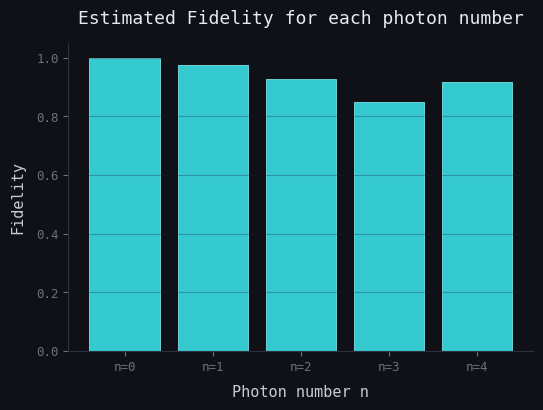

Estimated Fidelity for n=2: 0.9285209050517551


In [62]:
confusion_matrix = np.array([
    [2010,    1,    0,    0,    0],
    [   1, 1999,    2,    0,    0],
    [   0,   49, 1909,   35,    0],
    [   0,    0,   58, 1872,   82],
    [   0,    0,    1,  164, 1817]
], dtype=int)

N_k = confusion_matrix.sum(axis=1, keepdims=True)

probabilities_estimated = confusion_matrix / N_k

Fidelity_n = lambda n: probabilities_estimated[n,n] - sum(probabilities_estimated[n+1:,n])

plt.figure(figsize=(6, 4))
plt.bar(range(5), [Fidelity_n(n) for n in range(5)], color="#35c9d0", edgecolor="#79e3e7", linewidth=0.6)
plt.xticks(range(5), [f"n={n}" for n in range(5)])
plt.xlabel("Photon number n")
plt.ylabel("Fidelity")
plt.title("Estimated Fidelity for each photon number")
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Estimated Fidelity for n=2:", Fidelity_n(2))

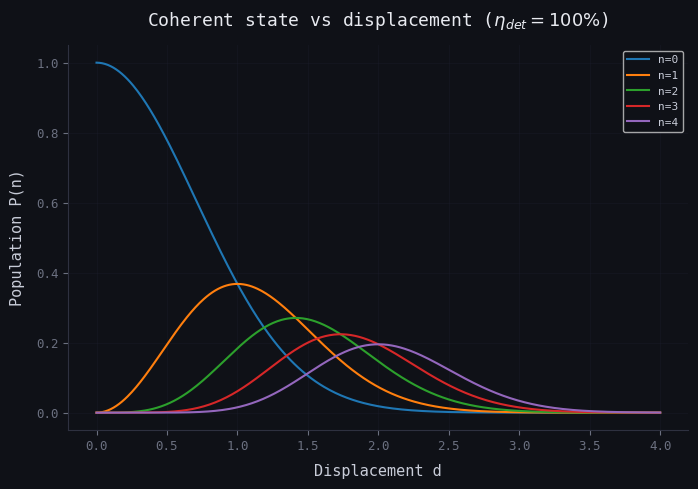

In [45]:
displacements = np.linspace(0, 4, 400)
loss_det = 0.0
Fs = []

n_size = len(probabilities_estimated[0])
P_coherents = []
for d in displacements:
    coherent = Vacuum(0) >> Dgate(0, d) >> Attenuator(0, 1 - loss_det)

    rho_coherent = coherent.normalize().dm().fock_array(50)
    pop_coherent = np.real(np.diagonal(rho_coherent))

    P_coherent = pop_coherent[:n_size]
    P_coherents.append(P_coherent)

P_coherents = np.array(P_coherents, dtype=float).reshape(len(displacements), n_size)

plt.figure(figsize=(8, 5))
for n in range(n_size):
    plt.plot(displacements, P_coherents[:, n], label=f"n={n}")
plt.xlabel("Displacement d")
plt.ylabel("Population P(n)")
plt.title(rf"Coherent state vs displacement ($\eta_{{det}}={100 * (1 - loss_det):.0f}\%$)")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)

plt.show()



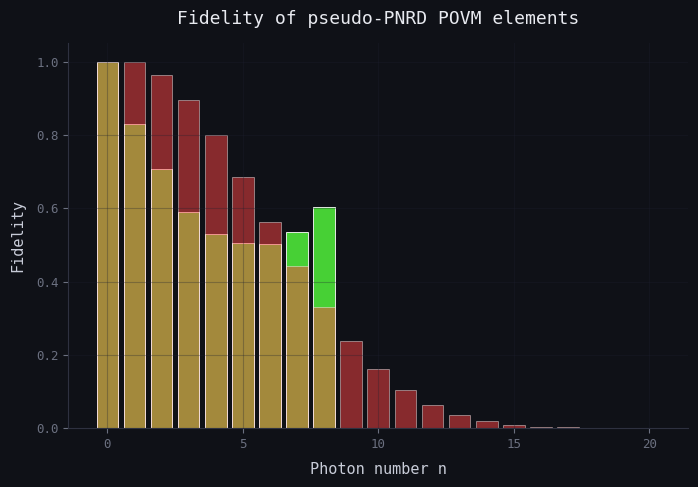

Estimated Fidelity for n=2 (experimental): 0.7069625414843417
Estimated Fidelity for n=2 (ideal): 0.9642857142857143


In [58]:
Fidelity_n = lambda n, P_PNRD: P_PNRD[n,n] - sum(P_PNRD[n+1:,n])
prob_PNRD_exp = prob_pPNRD(use_data=True, k_max=50, n_max=9)
prob_PNRD_ideal = prob_pPNRD(use_data=False, M=28, eta=1.0, k_max=50, n_max=20)

Fs = [Fidelity_n(n, prob_PNRD_exp) for n in range(prob_PNRD_exp.shape[0])]
Fs_ideal = [Fidelity_n(n, prob_PNRD_ideal) for n in range(prob_PNRD_ideal.shape[0])]

plt.figure(figsize=(8, 5))
plt.bar(range(len(Fs)), Fs, color="#47d035", edgecolor="#ffffff", linewidth=0.6)
plt.bar(range(len(Fs_ideal)), Fs_ideal, color="#ff4343", edgecolor="#ffffff", linewidth=0.6, alpha=0.5)
plt.xlabel("Photon number n")
plt.ylabel("Fidelity")
plt.title("Fidelity of pseudo-PNRD POVM elements")
plt.grid(True, alpha=0.3)
plt.show()

print("Estimated Fidelity for n=2 (experimental):", Fidelity_n(2, prob_PNRD_exp))
print("Estimated Fidelity for n=2 (ideal):", Fidelity_n(2, prob_PNRD_ideal))

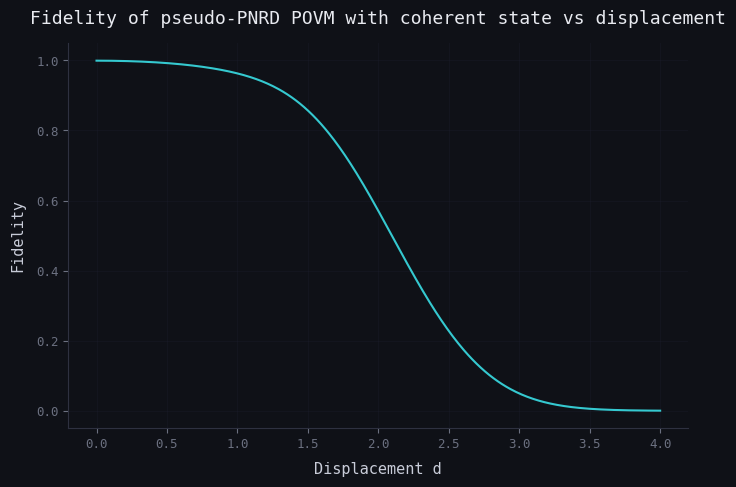

Estimated Fidelity for d=1.0: 0.9623593697541137


In [73]:
P_PNRD = probabilities_estimated
#P_PNRD = prob_PNRD_exp
#P_PNRD = prob_PNRD_ideal

n_max = len(P_PNRD[:,0])

Fidelities = []
for d in displacements:
    coherent = Vacuum(0) >> Dgate(0, d) >> Attenuator(0, 1 - loss_det)

    rho_coherent = coherent.normalize().dm().fock_array(50)
    pop_coherent = np.real(np.diagonal(rho_coherent))

    P_coherent = pop_coherent[:n_max]
    F = 0.0
    for n in range(n_max):
        F += (P_PNRD[n,n] - np.sum(P_PNRD[n+1:,n])) * P_coherent[n]
    Fidelities.append(F)

plt.figure(figsize=(8, 5))
plt.plot(displacements, Fidelities, color="#35c9d0", linewidth=1.5)
plt.xlabel("Displacement d")
plt.ylabel("Fidelity")
plt.title("Fidelity of pseudo-PNRD POVM with coherent state vs displacement")
plt.grid(True, alpha=0.3)
plt.show()

print("Estimated Fidelity for d=1.0:", Fidelities[np.argmin(np.abs(displacements - 1.0))])
